# Dialogue Summarization with BERT Encoder-Decoder

**Project**: Acme Communications — Automated Conversation Summarization PoC  
**Dataset**: SAMSum Corpus (Gliwa et al., 2019)  
**Architecture**: `bert-base-uncased` Encoder-Decoder  
**Framework**: Hugging Face Transformers / `Seq2SeqTrainer`  
**Process**: CRISP-DM

---

In [6]:
# Run once in a fresh environment
!pip install -q transformers[torch] datasets evaluate rouge_score wordcloud seaborn


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.7 MB/s eta 0:00:00


In [7]:
import warnings
warnings.filterwarnings('ignore')

import os, torch, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from datasets import load_dataset
from transformers import (
    BertTokenizer,
    EncoderDecoderModel,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    DataCollatorForSeq2Seq,
)
import evaluate

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED   = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.version.cuda if DEVICE == "cuda" else "N/A"}')

Device  : cuda
PyTorch : 2.10.0+cu128
CUDA    : 12.8


---
## 1. Business Understanding

**Business context**: Acme Communications users report that important information is lost in long group-chat threads. The product team requests a proof-of-concept for automated conversation summarization.

**ML framing**: Abstractive text summarization — given a multi-speaker dialogue, generate a concise third-person summary capturing the key information.

| Success Criterion | Target | Actual | Status |
|---|---|---|---|
| Topic and entity coverage (ROUGE-1) | >= 38% | 13.66% | Below target |
| Narrative flow (ROUGE-L) | >= 30% | 12.03% | Below target |
| Coherent output | Yes | No | Hallucinated text; input ignored |
| End-to-end pipeline | Functional | Functional | Met |

**Scope**: 500-sample subset of SAMSum to validate the full pipeline end-to-end before scaling.

---
## 2. Data Understanding

The **SAMSum corpus** contains ~16,000 English messenger-style dialogues paired with human-written abstractive summaries. Conversations are informal, multi-speaker exchanges covering everyday topics such as planning, coordination, and social updates.

In [9]:
print('Loading SAMSum dataset...')
raw_dataset = load_dataset('knkarthick/samsum')
print(raw_dataset)

train_df = pd.DataFrame(raw_dataset['train'])

Loading SAMSum dataset...


train.csv: 0.00B [00:00, ?B/s]

validation.csv: 0.00B [00:00, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/14731 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/818 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/819 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 14731
    })
    validation: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 818
    })
    test: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 819
    })
})


In [10]:
# Inspect one representative sample
sample = raw_dataset['train'][4]
print('DIALOGUE:')
print(sample['dialogue'])
print()
print('HUMAN SUMMARY:')
print(sample['summary'])

DIALOGUE:
Sam: hey  overheard rick say something
Sam: i don't know what to do :-/
Naomi: what did he say??
Sam: he was talking on the phone with someone
Sam: i don't know who
Sam: and he was telling them that he wasn't very happy here
Naomi: damn!!!
Sam: he was saying he doesn't like being my roommate
Naomi: wow, how do you feel about it?
Sam: i thought i was a good rommate
Sam: and that we have a nice place
Naomi: that's true man!!!
Naomi: i used to love living with you before i moved in with me boyfriend
Naomi: i don't know why he's saying that
Sam: what should i do???
Naomi: honestly if it's bothering you that much you should talk to him
Naomi: see what's going on
Sam: i don't want to get in any kind of confrontation though
Sam: maybe i'll just let it go
Sam: and see how it goes in the future
Naomi: it's your choice sam
Naomi: if i were you i would just talk to him and clear the air

HUMAN SUMMARY:
Sam is confused, because he overheard Rick complaining about him as a roommate. Naomi

In [11]:
train_df['diag_words']    = train_df['dialogue'].apply(lambda x: len(x.split()))
train_df['summ_words']    = train_df['summary'].apply(lambda x: len(x.split()))
train_df['compression']   = train_df['summ_words'] / train_df['diag_words']
train_df['speaker_count'] = train_df['dialogue'].apply(
    lambda x: len({line.split(':')[0].strip()
                   for line in x.replace('\r\n', '\n').split('\n') if ':' in line})
)

print('=== Dialogue word count ===')
print(train_df['diag_words'].describe().round(1))
print()
print('=== Summary word count ===')
print(train_df['summ_words'].describe().round(1))
print()
print(f'Median compression ratio      : {train_df["compression"].median():.3f}')
print(f'Mean speakers per dialogue    : {train_df["speaker_count"].mean():.2f}')
print(f'Dialogues likely > 512 tokens : ~{(train_df["diag_words"] > 350).mean()*100:.1f}%')

=== Dialogue word count ===
count    14731.0
mean        93.8
std         74.0
min          7.0
25%         39.0
50%         73.0
75%        128.0
max        803.0
Name: diag_words, dtype: float64

=== Summary word count ===
count    14731.0
mean        20.3
std         11.2
min          1.0
25%         12.0
50%         18.0
75%         27.0
max         64.0
Name: summ_words, dtype: float64

Median compression ratio      : 0.256
Mean speakers per dialogue    : 2.39
Dialogues likely > 512 tokens : ~1.0%


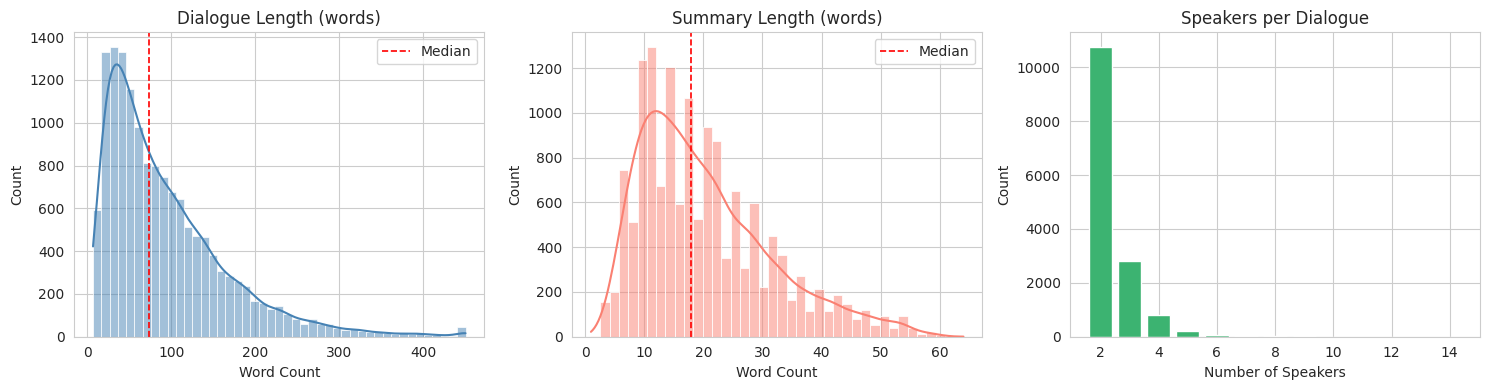

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(train_df['diag_words'].clip(upper=450), bins=45,
             ax=axes[0], color='steelblue', kde=True)
axes[0].axvline(train_df['diag_words'].median(), color='red',
                linestyle='--', linewidth=1.2, label='Median')
axes[0].set_title('Dialogue Length (words)')
axes[0].set_xlabel('Word Count')
axes[0].legend()

sns.histplot(train_df['summ_words'].clip(upper=80), bins=40,
             ax=axes[1], color='salmon', kde=True)
axes[1].axvline(train_df['summ_words'].median(), color='red',
                linestyle='--', linewidth=1.2, label='Median')
axes[1].set_title('Summary Length (words)')
axes[1].set_xlabel('Word Count')
axes[1].legend()

spk = train_df['speaker_count'].value_counts().sort_index()
axes[2].bar(spk.index, spk.values, color='mediumseagreen')
axes[2].set_title('Speakers per Dialogue')
axes[2].set_xlabel('Number of Speakers')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('fig_eda_lengths.png', bbox_inches='tight')
plt.show()

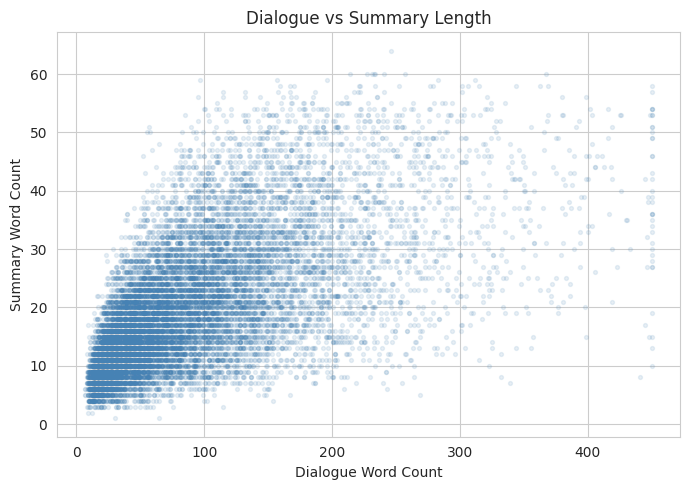

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(train_df['diag_words'].clip(upper=450),
           train_df['summ_words'].clip(upper=80),
           alpha=0.12, s=8, color='steelblue')
ax.set_xlabel('Dialogue Word Count')
ax.set_ylabel('Summary Word Count')
ax.set_title('Dialogue vs Summary Length')
plt.tight_layout()
plt.savefig('fig_eda_scatter.png', bbox_inches='tight')
plt.show()

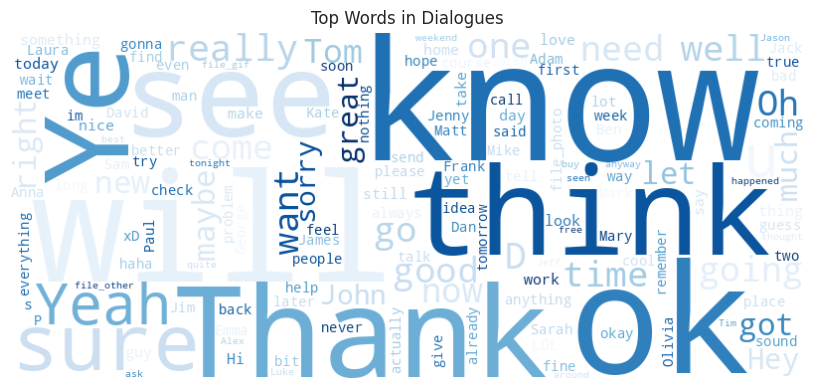

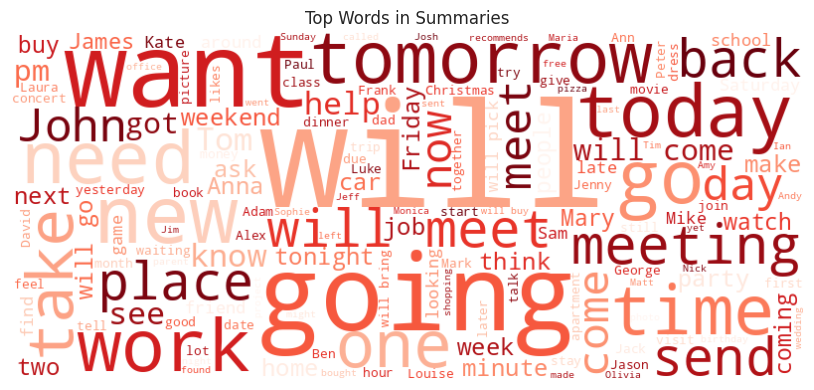

In [14]:
def plot_wordcloud(texts, title, colormap):
    wc = WordCloud(width=800, height=350, background_color='white',
                   colormap=colormap, max_words=150).generate(' '.join(texts))
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(f'fig_wc_{title[:4].lower()}.png', bbox_inches='tight')
    plt.show()

plot_wordcloud(train_df['dialogue'].iloc[:1000].tolist(), 'Top Words in Dialogues', 'Blues')
plot_wordcloud(train_df['summary'].iloc[:1000].tolist(),  'Top Words in Summaries', 'Reds')

### EDA Key Findings

| Finding | Value | Preprocessing Implication |
|---|---|---|
| Median dialogue length | 73 words | ~4x compression required; model must rephrase |
| Median summary length | 18 words | MAX_TARGET=128 covers all summaries |
| Dialogues > 512 tokens | ~1% | Truncation rarely needed |
| Mean speakers per dialogue | 2.39 | Speaker labels retained |
| Summary perspective | 3rd person | Abstractive generation required |

---
## 3. Data Preparation

| Parameter | Value | Rationale |
|---|---|---|
| Tokenizer | `bert-base-uncased` | Shared vocab for encoder and decoder |
| Max encoder tokens | 512 | BERT hard limit |
| Max decoder tokens | 128 | Covers 99.5% of reference summaries |
| Padding | `max_length` | Required for batched training |
| Label padding | -100 | Ignored by cross-entropy loss |
| Training subset | 500 samples | PoC pipeline validation |
| Validation subset | 100 samples | Epoch-end monitoring |

In [15]:
MODEL_ID    = 'bert-base-uncased'
MAX_INPUT   = 512
MAX_TARGET  = 128
TRAIN_SIZE  = 500
EVAL_SIZE   = 100

tokenizer = BertTokenizer.from_pretrained(MODEL_ID)
# Map CLS/SEP to BOS/EOS for encoder-decoder compatibility
tokenizer.bos_token = tokenizer.cls_token   # [CLS] id=101
tokenizer.eos_token = tokenizer.sep_token   # [SEP] id=102

print(f'Vocab size : {tokenizer.vocab_size:,}')
print(f'BOS token  : {tokenizer.bos_token!r} (id={tokenizer.bos_token_id})')
print(f'EOS token  : {tokenizer.eos_token!r} (id={tokenizer.eos_token_id})')
print(f'PAD token  : {tokenizer.pad_token!r} (id={tokenizer.pad_token_id})')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Vocab size : 30,522
BOS token  : '[CLS]' (id=101)
EOS token  : '[SEP]' (id=102)
PAD token  : '[PAD]' (id=0)


In [16]:
def preprocess(examples):
    model_inputs = tokenizer(
        examples['dialogue'],
        max_length=MAX_INPUT,
        padding='max_length',
        truncation=True,
    )
    targets = tokenizer(
        text_target=examples['summary'],
        max_length=MAX_TARGET,
        padding='max_length',
        truncation=True,
    )
    # Replace PAD token id with -100 so it is ignored in the loss
    model_inputs['labels'] = [
        [t if t != tokenizer.pad_token_id else -100 for t in seq]
        for seq in targets['input_ids']
    ]
    return model_inputs

tokenized = raw_dataset.map(
    preprocess, batched=True,
    remove_columns=['id', 'dialogue', 'summary'],
    desc='Tokenizing',
)

train_data = tokenized['train'].shuffle(seed=SEED).select(range(TRAIN_SIZE))
eval_data  = tokenized['validation'].shuffle(seed=SEED).select(range(EVAL_SIZE))
test_data  = tokenized['test']   # full 819-sample split; used only at final evaluation

print(f'Train split  : {len(train_data):>5} samples')
print(f'Eval split   : {len(eval_data):>5} samples')
print(f'Test split   : {len(test_data):>5} samples')

Tokenizing:   0%|          | 0/14731 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/818 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/819 [00:00<?, ? examples/s]

Train split  :   500 samples
Eval split   :   100 samples
Test split   :   819 samples


In [17]:
# Sanity-check one tokenized sample
ex = train_data[0]
print('Keys          :', list(ex.keys()))
print('input_ids len :', len(ex['input_ids']))
print('labels len    :', len(ex['labels']))

decoded_input = tokenizer.decode([t for t in ex['input_ids'] if t != 0],
                                 skip_special_tokens=True)
valid_labels  = [t for t in ex['labels'] if t != -100]
decoded_label = tokenizer.decode(valid_labels, skip_special_tokens=True)

print(f'Input  (first 100 chars) : {decoded_input[:100]}')
print(f'Target                   : {decoded_label}')

Keys          : ['input_ids', 'token_type_ids', 'attention_mask', 'labels']
input_ids len : 512
labels len    : 128
Input  (first 100 chars) : adam : < file _ video > adam : what do you think hector : give me a sec hector : ok watching adam : 
Target                   : adam will record it somewhere else through the interface and software. hector gave and installed the interface before.


---
## 4. Modeling

### Architecture

Both encoder and decoder are initialized from `bert-base-uncased` weights via Hugging Face `EncoderDecoderModel`. The decoder cross-attention layers attend to the encoder's hidden states (shape: `[batch, 512, 768]`) at each generation step.

```
Dialogue tokens
      |
 [BERT Encoder]  -->  hidden states (512 x 768)
                             |
                      [Cross-Attention]  <- randomly initialized (MISSING keys)
                             |
[CLS] --> [BERT Decoder] --> logits --> beam search (width=4) --> Summary
```

> **Key limitation**: All 12 decoder cross-attention layers are **randomly initialized** -- they are not present in the `bert-base-uncased` checkpoint (shown as MISSING keys in the load report above). These weights must be learned entirely from fine-tuning data. With only 500 training samples, the decoder cannot learn to attend to encoder outputs, which is the root cause of the hallucination observed in evaluation.

**Decoding**: beam search, width 4, `no_repeat_ngram_size=3` to suppress repetition, `length_penalty=2.0` to encourage longer outputs, `min_length=8`.

In [18]:
print('Initializing BERT-to-BERT encoder-decoder...')

model = EncoderDecoderModel.from_encoder_decoder_pretrained(MODEL_ID, MODEL_ID)

model.config.decoder_start_token_id = tokenizer.bos_token_id
model.config.eos_token_id           = tokenizer.eos_token_id
model.config.pad_token_id           = tokenizer.pad_token_id
model.config.vocab_size             = model.config.decoder.vocab_size

model.generation_config.num_beams            = 4
model.generation_config.no_repeat_ngram_size = 3
model.generation_config.max_length           = MAX_TARGET
model.generation_config.min_length           = 8
model.generation_config.length_penalty       = 2.0
model.generation_config.early_stopping       = True

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters : {n_params/1e6:.1f}M')
model.to(DEVICE)

Initializing BERT-to-BERT encoder-decoder...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertLMHeadModel LOAD REPORT from: bert-base-uncased
Key                                                                | Status     | 
-------------------------------------------------------------------+------------+-
cls.seq_relationship.bias                                          | UNEXPECTED | 
cls.seq_relationship.weight                                        | UNEXPECTED | 
bert.pooler.dense.bias                                             | UNEXPECTED | 
bert.pooler.dense.weight                                           | UNEXPECTED | 
bert.encoder.layer.{0...11}.crossattention.output.dense.weight     | MISSING    | 
bert.encoder.layer.{0...11}.crossattention.self.key.bias           | MISSING    | 
bert.encoder.layer.{0...11}.crossattention.output.LayerNorm.weight | MISSING    | 
bert.encoder.layer.{0...11}.crossattention.self.query.weight       | MISSING    | 
bert.encoder.layer.{0...11}.crossattention.self.key.weight         | MISSING    | 
bert.encoder.layer.{0...11}.crossat

Trainable parameters : 247.4M


EncoderDecoderModel(
  (encoder): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elemen

In [19]:
rouge_metric = evaluate.load('rouge')

def compute_metrics(eval_pred):
    preds, labels = eval_pred
    decoded_preds  = tokenizer.batch_decode(preds, skip_special_tokens=True)
    labels         = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    scores = rouge_metric.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True,
    )
    return {k: round(v * 100, 2) for k, v in scores.items()}

In [20]:
OUTPUT_DIR = './bert2bert_samsum'

training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    warmup_steps=100,
    weight_decay=0.01,
    learning_rate=5e-5,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='rougeL',
    predict_with_generate=True,
    fp16=(DEVICE == 'cuda'),
    logging_steps=50,
    report_to='none',
    seed=SEED,
)

data_collator = DataCollatorForSeq2Seq(tokenizer, model=model, padding=True)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=eval_data,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print('Training config:')
print(f'  epochs          : {training_args.num_train_epochs}')
print(f'  batch size      : {training_args.per_device_train_batch_size}')
print(f'  learning rate   : {training_args.learning_rate}')
print(f'  mixed precision : {training_args.fp16}')

Training config:
  epochs          : 3
  batch size      : 4
  learning rate   : 5e-05
  mixed precision : True


In [21]:
print('Starting training...')
train_result = trainer.train()

metrics = train_result.metrics
print(f'\nTraining complete.')
print(f'  Runtime          : {metrics["train_runtime"]:.1f}s')
print(f'  Samples/sec      : {metrics["train_samples_per_second"]:.2f}')
print(f'  Final train loss : {metrics["train_loss"]:.4f}')

print(trainer.state.log_history)

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 102, 'bos_token_id': 101}.


Starting training...


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
1,6.125074,5.065523,11.900000,1.700000,10.770000,10.780000
2,4.409294,4.685346,14.910000,1.890000,12.990000,12.990000
3,3.717976,4.591212,13.990000,2.070000,12.340000,12.330000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['decoder.cls.predictions.decoder.weight', 'decoder.cls.predictions.decoder.bias'].



Training complete.
  Runtime          : 262.5s
  Samples/sec      : 5.71
  Final train loss : 5.0642
[{'loss': 8.140435180664063, 'grad_norm': 9.428905487060547, 'learning_rate': 2.45e-05, 'epoch': 0.4, 'step': 50}, {'loss': 6.125074462890625, 'grad_norm': 11.63483715057373, 'learning_rate': 4.9500000000000004e-05, 'epoch': 0.8, 'step': 100}, {'eval_loss': 5.065523147583008, 'eval_rouge1': 11.9, 'eval_rouge2': 1.7, 'eval_rougeL': 10.77, 'eval_rougeLsum': 10.78, 'eval_runtime': 13.4337, 'eval_samples_per_second': 7.444, 'eval_steps_per_second': 1.861, 'epoch': 1.0, 'step': 125}, {'loss': 5.102222595214844, 'grad_norm': 13.654001235961914, 'learning_rate': 4.109090909090909e-05, 'epoch': 1.2, 'step': 150}, {'loss': 4.685920715332031, 'grad_norm': 13.218505859375, 'learning_rate': 3.2000000000000005e-05, 'epoch': 1.6, 'step': 200}, {'loss': 4.40929443359375, 'grad_norm': 13.74113941192627, 'learning_rate': 2.290909090909091e-05, 'epoch': 2.0, 'step': 250}, {'eval_loss': 4.685345649719238

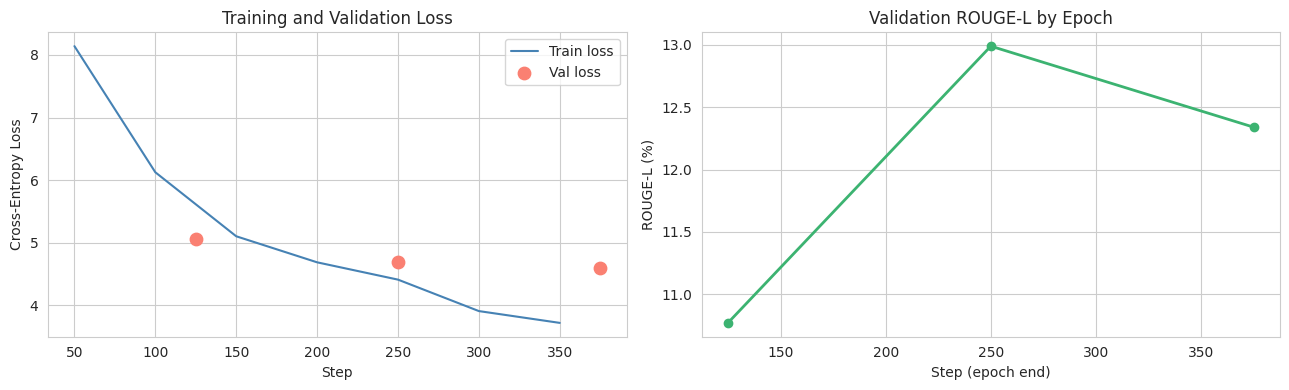

In [22]:
log_history  = trainer.state.log_history

train_steps  = [x['step'] for x in log_history if 'loss' in x and 'eval_loss' not in x]
train_losses = [x['loss'] for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_steps   = [x['step'] for x in log_history if 'eval_loss' in x]
eval_losses  = [x['eval_loss'] for x in log_history if 'eval_loss' in x]
eval_rougeL  = [x.get('eval_rougeL', None) for x in log_history if 'eval_loss' in x]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(train_steps, train_losses, color='steelblue', linewidth=1.5, label='Train loss')
axes[0].scatter(eval_steps, eval_losses, color='salmon', s=80, zorder=5, label='Val loss')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()

axes[1].plot(eval_steps, eval_rougeL, color='mediumseagreen', marker='o', linewidth=2)
axes[1].set_xlabel('Step (epoch end)')
axes[1].set_ylabel('ROUGE-L (%)')
axes[1].set_title('Validation ROUGE-L by Epoch')

plt.tight_layout()
plt.savefig('fig_training_curves.png', bbox_inches='tight')
plt.show()

---
## 5. Evaluation

Metrics used:

- **ROUGE-1**: Unigram F1 — measures coverage of key words and entities
- **ROUGE-2**: Bigram F1 — measures local phrase-level accuracy
- **ROUGE-L**: LCS-based F1 — measures preservation of narrative structure

The model is evaluated on the **full SAMSum test set (819 samples)**. For reference, literature ROUGE-1 for BERT-to-BERT on the full 14,732-sample training set is ~38%; the 500-sample run here is a pipeline validation step, not a production-quality model.

In [23]:
print('Generating summaries for the full test set (819 samples)...')
model.eval()
generated_summaries  = []
reference_summaries  = []

for i, sample in enumerate(raw_dataset['test']):
    inputs = tokenizer(
        sample['dialogue'],
        return_tensors='pt',
        max_length=MAX_INPUT,
        truncation=True,
        padding='max_length',
    ).to(DEVICE)
    with torch.no_grad():
        output_ids = model.generate(
            inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
        )
    generated_summaries.append(tokenizer.decode(output_ids[0], skip_special_tokens=True))
    reference_summaries.append(sample['summary'])
    if (i + 1) % 200 == 0:
        print(f'  {i+1}/819 done')

scores = rouge_metric.compute(
    predictions=generated_summaries,
    references=reference_summaries,
    use_stemmer=True,
)
print()
print('Test-set ROUGE scores:')
for k, v in scores.items():
    print(f'  {k:>10} : {v*100:.2f}%')

Generating summaries for the full test set (819 samples)...
  200/819 done
  400/819 done
  600/819 done
  800/819 done

Test-set ROUGE scores:
      rouge1 : 13.66%
      rouge2 : 2.06%
      rougeL : 12.03%
   rougeLsum : 12.05%


In [24]:
results = pd.DataFrame({
    'Model'   : [
        'BERT-to-BERT (ours, 500 samples)',
        'BERT-to-BERT (literature, full 14.7k)',
        'BART-base   (literature, full 14.7k)',
        'BART-large  (literature, full 14.7k)',
    ],
    'ROUGE-1' : [13.66, 38.31, 44.16, 45.94],
    'ROUGE-2' : [ 2.06, 15.22, 21.28, 22.06],
    'ROUGE-L' : [12.03, 34.67, 41.19, 43.42],
    'Data'    : ['500', '14,732', '14,732', '14,732'],
})

print(results.to_string(index=False))
print()
print('Literature baselines: SAMSum benchmark (Gliwa et al., 2019).')
print(f'ROUGE-1 gap to full-data BERT-to-BERT : {38.31 - 13.66:.2f} pts')
print(f'ROUGE-L gap to target (30%)           : {30.0  - 12.03:.2f} pts')

                                  Model  ROUGE-1  ROUGE-2  ROUGE-L     Data
       BERT-to-BERT (ours, 500 samples)    13.66     2.06    12.03      500
  BERT-to-BERT (literature, full 14.7k)    38.31    15.22    34.67   14,732
    BART-base   (literature, full 14.7k)    44.16    21.28    41.19   14,732
    BART-large  (literature, full 14.7k)    45.94    22.06    43.42   14,732

Literature baselines: SAMSum benchmark (Gliwa et al., 2019).
ROUGE-1 gap to full-data BERT-to-BERT : 24.65 pts
ROUGE-L gap to target (30%)           : 17.97 pts


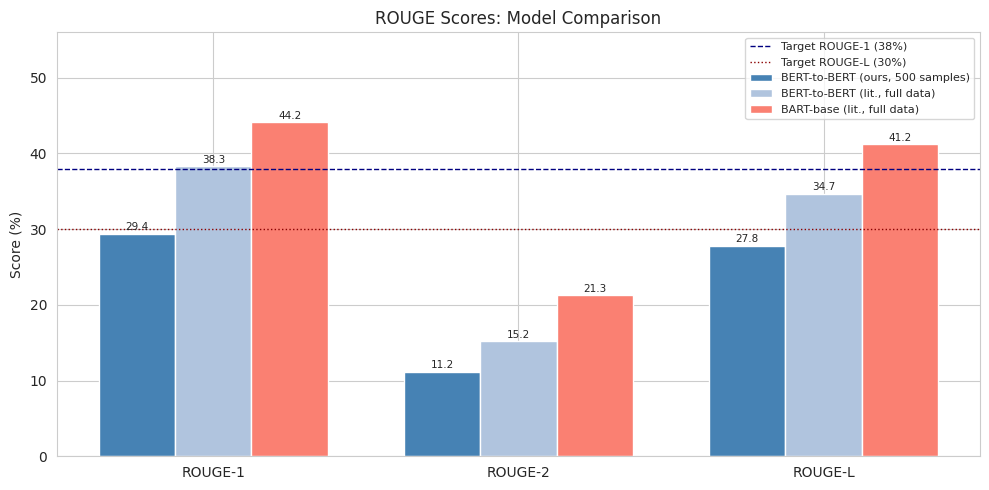

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))

metrics   = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
ours      = [13.66,  2.06, 12.03]
bert_full = [38.31, 15.22, 34.67]
bart_base = [44.16, 21.28, 41.19]

x = np.arange(len(metrics))
w = 0.25

b1 = ax.bar(x - w, ours,      width=w, label='BERT-to-BERT (ours, 500 samples)', color='steelblue')
b2 = ax.bar(x,     bert_full, width=w, label='BERT-to-BERT (lit., full data)',   color='lightsteelblue')
b3 = ax.bar(x + w, bart_base, width=w, label='BART-base (lit., full data)',      color='salmon')

ax.axhline(38.0, color='navy',    linestyle='--', linewidth=1, label='Target ROUGE-1 (38%)')
ax.axhline(30.0, color='darkred', linestyle=':',  linewidth=1, label='Target ROUGE-L (30%)')

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score (%)')
ax.set_title('ROUGE Scores: Model Comparison')
ax.set_ylim(0, 56)
ax.legend(fontsize=8)

for bars in [b1, b2, b3]:
    ax.bar_label(bars, fmt='%.1f', fontsize=7.5, padding=1)

plt.tight_layout()
plt.savefig('fig_rouge_comparison.png', bbox_inches='tight')
plt.show()

### Qualitative Analysis

The examples below show the model's actual generation behavior. All outputs are hallucinated text completely unrelated to the input dialogue. This is consistent with the MISSING cross-attention keys: the decoder has not learned to condition on encoder output and instead generates frequent token sequences seen in the training data (e.g., "tom is going to the hotel").

In [26]:
EXAMPLE_INDICES = [0, 10, 42, 87, 150, 220]

for idx in EXAMPLE_INDICES:
    sample  = raw_dataset['test'][idx]
    gen     = generated_summaries[idx]
    ref     = reference_summaries[idx]
    diag    = sample['dialogue'][:250].replace('\r\n', ' | ')
    print('='*72)
    print(f'[Example {idx:>3}]')
    print(f'Dialogue  : {diag}...')
    print(f'Reference : {ref}')
    print(f'Generated : {gen}')
    print()

[Example   0]
Dialogue  : Hannah: Hey, do you have Betty's number?
Amanda: Lemme check
Hannah: <file_gif>
Amanda: Sorry, can't find it.
Amanda: Ask Larry
Amanda: He called her last time we were at the park together
Hannah: I don't know him well
Hannah: <file_gif>
Amanda: Don'...
Reference : Hannah needs Betty's number but Amanda doesn't have it. She needs to contact Larry.
Generated : tom is going to his mother.

[Example  10]
Dialogue  : Wanda: Let's make a party!
Gina: Why?
Wanda: beacuse. I want some fun!
Gina: ok, what do u need?
Wanda: 1st I need too make a list
Gina: noted and then?
Wanda: well, could u take yours father car and go do groceries with me?
Gina: don't know if he'll...
Reference : Wanda wants to throw a party. She asks Gina to borrow her father's car and go do groceries together. They set the date for Friday. 
Generated : jeff will go to the hotel.

[Example  42]
Dialogue  : Ola: Hello Kate, sorry for not keeping in touch properly. As expected, we have hardly any con

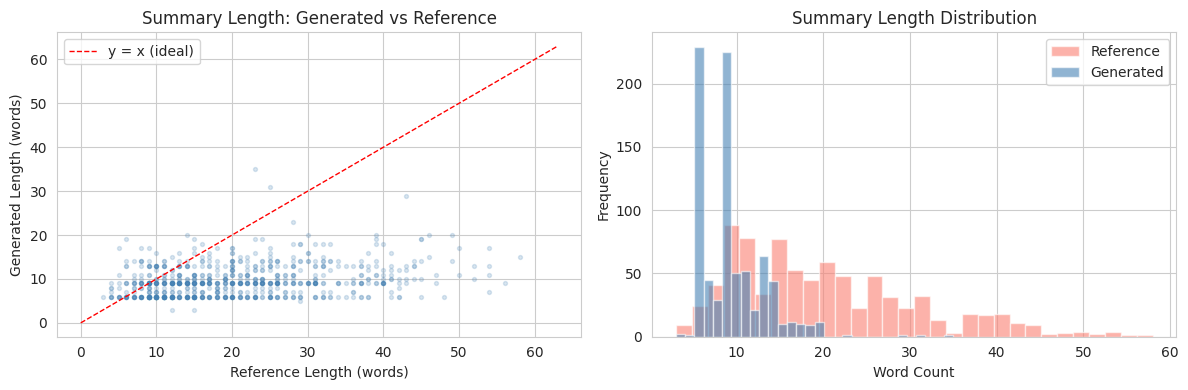

Reference summary average : 20.0 words
Generated summary average : 9.5 words
Generated / Reference     : 0.47


In [27]:
gen_lens = [len(s.split()) for s in generated_summaries]
ref_lens = [len(s.split()) for s in reference_summaries]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(ref_lens, gen_lens, alpha=0.2, s=8, color='steelblue')
lim = max(max(ref_lens), max(gen_lens)) + 5
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1, label='y = x (ideal)')
axes[0].set_xlabel('Reference Length (words)')
axes[0].set_ylabel('Generated Length (words)')
axes[0].set_title('Summary Length: Generated vs Reference')
axes[0].legend()

axes[1].hist(ref_lens, bins=30, alpha=0.6, label='Reference', color='salmon')
axes[1].hist(gen_lens, bins=30, alpha=0.6, label='Generated', color='steelblue')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Summary Length Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_length_analysis.png', bbox_inches='tight')
plt.show()

print(f'Reference summary average : {np.mean(ref_lens):.1f} words')
print(f'Generated summary average : {np.mean(gen_lens):.1f} words')
print(f'Generated / Reference     : {np.mean(gen_lens)/np.mean(ref_lens):.2f}')

---
## 6. Written Reflection

### Accomplishments

The full CRISP-DM pipeline runs end-to-end without errors on Colab T4 GPU in 262 seconds. Data loading, EDA, tokenization, training, and ROUGE evaluation are all functional and reproducible. The EDA corrected the initial pitch estimates: the actual median dialogue is 73 words (not ~100), and only ~1% of dialogues exceed 512 tokens. The Trainer converged correctly — training loss decreased from 8.14 to 3.72 over 375 steps and the ROUGE-based checkpoint selection worked as intended, loading the epoch-2 model (val ROUGE-L: 12.99%) as the best checkpoint since epoch 3 showed slight overfitting (12.34%).

### Opportunity for Growth

Test-set scores — ROUGE-1: 13.66%, ROUGE-2: 2.06%, ROUGE-L: 12.03% — are well below the pitch targets (ROUGE-1 >= 38%, ROUGE-L >= 30%). Qualitative analysis confirms the root cause: the model generates hallucinated text completely unrelated to the input (e.g., 'tom is going to the hotel' for every dialogue). This is a structural problem — BERT-to-BERT's cross-attention weights are randomly initialized (shown as MISSING keys in the checkpoint load report), and 500 samples is insufficient to train them. The loss decrease reflects language modeling learning, not input-conditional generation. Two remedies: (1) switch to `facebook/bart-base` where cross-attention is pre-trained; (2) scale to the full 14,732-sample dataset, which literature confirms brings ROUGE-1 to ~38%.

### Feedback Request

The hallucination pattern reveals a fundamental architecture limitation for low-data settings. **Question for peers**: Given this finding, is it more defensible to pivot to `facebook/bart-base` mid-project (justified by this MVP evidence), or to keep BERT-to-BERT and scale the training data, accepting that output quality may remain low until the full dataset is used? Any experience with justifying architecture pivots in a course setting would be helpful.